# 🏎️ Experimental Vehicle Physics
## Step 1: Engine + Acceleration + Braking

We start simple. Before tires, slip angles, and all the complex stuff,
we need to understand how an engine produces torque and how that torque
moves a car forward or slows it down.

### Concepts we cover here:
- **RPM** - how fast the engine spins
- **Torque curve** - engine output at different RPMs
- **Gear ratios** - how torque is multiplied down to wheels
- **Longitudinal force** - the push/pull force along the car's direction
- **Simple integration** - velocity and position update each frame

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display
import ipywidgets as widgets

## The Torque Curve

A real engine doesn't produce the same torque at all RPMs.
It has a personality. An F1 engine is a HIGH RPM screamer -
it produces peak power at very high RPM (around 10,000-15,000 RPM).

We use a mathematical formula to fake this curve with tuneable parameters.
Think of it like drawing a hill shape with knobs to control:
- WHERE the peak is (which RPM)
- HOW TALL the peak is (max torque)
- HOW STEEP the sides are

Formula:  torque(rpm) = a + b * exp(-c * (rpm - d)^2)
- a = baseline torque (idle)
- b = peak height above baseline  
- c = width of the peak (narrow = peaky F1, wide = diesel truck)
- d = RPM where peak occurs

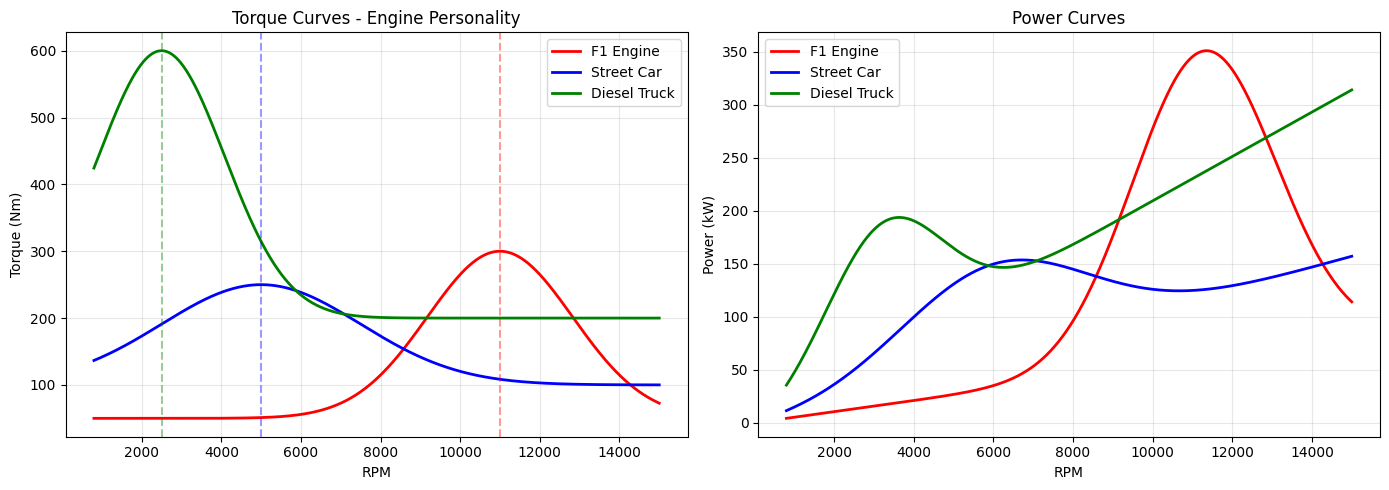

F1 peak torque:     300.0 Nm  at ~11,000 RPM
Street peak torque: 250.0 Nm  at ~5,000 RPM
Diesel peak torque: 600.0 Nm  at ~2,500 RPM

F1 peak power:      351.2 kW  (471 hp)


In [3]:
def torque_curve(rpm, a=50, b=250, c=0.00000015, d=11000):
    """
    Returns engine torque (Nm) at a given RPM.
    
    Parameters:
    -----------
    rpm : float - current engine RPM
    a   : float - baseline torque at idle (Nm)
    b   : float - extra torque at peak (Nm)
    c   : float - how narrow/wide the peak is
                  small c = wide peak (diesel truck feel)
                  large c = narrow peak (peaky F1 feel)
    d   : float - RPM at peak torque
    
    F1 character: high d (peak at high RPM), high c (narrow peak)
    Diesel character: low d (peak at low RPM), low c (wide peak)
    """
    return a + b * np.exp(-c * (rpm - d)**2)

# --- Let's visualize different engine personalities ---
rpm_range = np.linspace(800, 15000, 1000)

# F1 engine - screams at high RPM, narrow power band
torque_f1      = torque_curve(rpm_range, a=50,  b=250, c=0.00000015, d=11000)

# Street car - broad torque, peaks mid range
torque_street  = torque_curve(rpm_range, a=100, b=150, c=0.00000008, d=5000)

# Diesel truck - massive low end torque, falls off early
torque_diesel  = torque_curve(rpm_range, a=200, b=400, c=0.00000020, d=2500)

# --- Power = Torque * RPM * (pi/30) converts RPM to rad/s ---
power_f1       = torque_f1     * rpm_range * (np.pi / 30) / 1000  # kW
power_street   = torque_street * rpm_range * (np.pi / 30) / 1000
power_diesel   = torque_diesel * rpm_range * (np.pi / 30) / 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rpm_range, torque_f1,     color='red',    linewidth=2, label='F1 Engine')
ax1.plot(rpm_range, torque_street, color='blue',   linewidth=2, label='Street Car')
ax1.plot(rpm_range, torque_diesel, color='green',  linewidth=2, label='Diesel Truck')
ax1.set_xlabel('RPM')
ax1.set_ylabel('Torque (Nm)')
ax1.set_title('Torque Curves - Engine Personality')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(x=11000, color='red',   linestyle='--', alpha=0.4, label='F1 peak')
ax1.axvline(x=5000,  color='blue',  linestyle='--', alpha=0.4)
ax1.axvline(x=2500,  color='green', linestyle='--', alpha=0.4)

ax2.plot(rpm_range, power_f1,     color='red',   linewidth=2, label='F1 Engine')
ax2.plot(rpm_range, power_street, color='blue',  linewidth=2, label='Street Car')
ax2.plot(rpm_range, power_diesel, color='green', linewidth=2, label='Diesel Truck')
ax2.set_xlabel('RPM')
ax2.set_ylabel('Power (kW)')
ax2.set_title('Power Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"F1 peak torque:     {max(torque_f1):.1f} Nm  at ~11,000 RPM")
print(f"Street peak torque: {max(torque_street):.1f} Nm  at ~5,000 RPM")
print(f"Diesel peak torque: {max(torque_diesel):.1f} Nm  at ~2,500 RPM")
print(f"\nF1 peak power:      {max(power_f1):.1f} kW  ({max(power_f1)*1.341:.0f} hp)")

## The Gearbox

The engine spins way too fast to connect directly to the wheels.
The gearbox is just a **lookup table of ratios**.

Each gear ratio does two things simultaneously:
- **Divides** the RPM down (so wheels spin at reasonable speed)
- **Multiplies** the torque up (more grunt at the wheels)

Power stays the same (minus losses), but torque vs speed tradeoff changes.

F1 cars have 8 forward gears. Lower gears = more torque, less speed.
Higher gears = less torque, more speed.

wheel_torque = engine_torque * gear_ratio * final_drive_ratio
wheel_rpm    = engine_rpm    / gear_ratio / final_drive_ratio

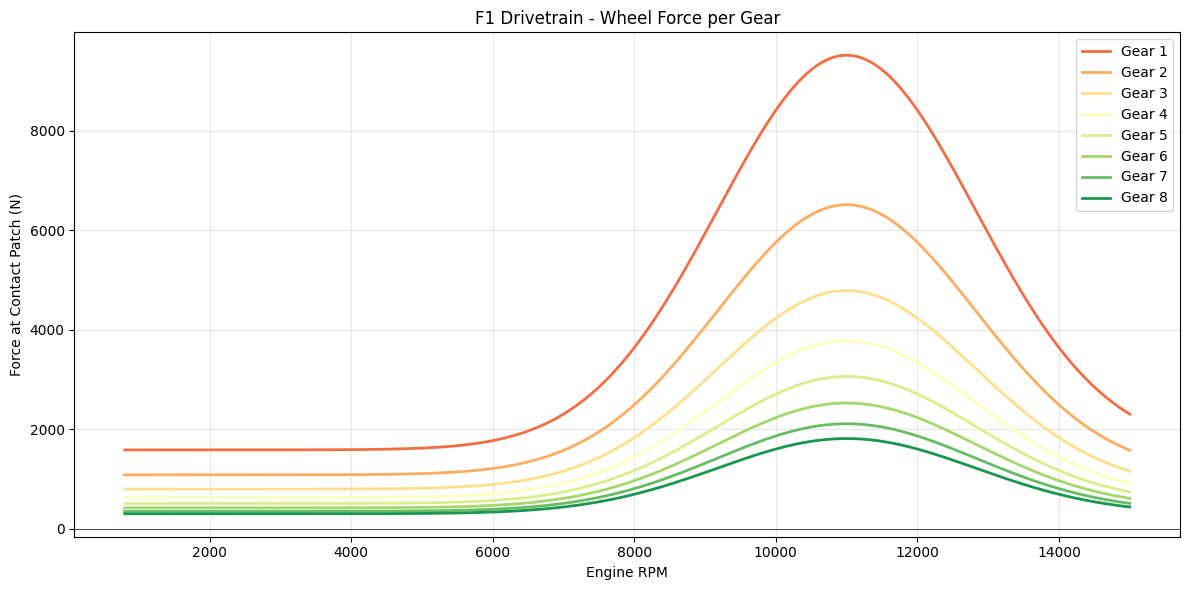

Force comparison at peak RPM (11,000):
  Gear 1:     9513 N  →  11.92 m/s²  (1.22g)
  Gear 2:     6510 N  →  8.16 m/s²  (0.83g)
  Gear 3:     4786 N  →  6.00 m/s²  (0.61g)
  Gear 4:     3775 N  →  4.73 m/s²  (0.48g)
  Gear 5:     3062 N  →  3.84 m/s²  (0.39g)
  Gear 6:     2527 N  →  3.17 m/s²  (0.32g)
  Gear 7:     2111 N  →  2.64 m/s²  (0.27g)
  Gear 8:     1813 N  →  2.27 m/s²  (0.23g)


In [4]:
# ── F1 GEAR RATIOS (realistic approximation) ──────────────────────────────
# Each number means: engine spins X times for every 1 wheel rotation
GEAR_RATIOS = {
    'R':  -2.50,   # Reverse
    'N':   0.00,   # Neutral
    1:     3.20,   # 1st - max torque multiplication, low speed
    2:     2.19,
    3:     1.61,
    4:     1.27,
    5:     1.03,
    6:     0.85,
    7:     0.71,
    8:     0.61    # 8th - least torque, max speed
}

FINAL_DRIVE_RATIO = 3.27   # differential ratio (always applied on top)
WHEEL_RADIUS      = 0.330  # meters (F1 wheel ~13 inch radius with tire)
CAR_MASS          = 798    # kg (F1 car minimum with driver 2024 rules)

def get_wheel_force(engine_rpm, gear, throttle=1.0):
    """
    Full drivetrain calculation:
    Engine RPM + Gear → Force at contact patch (Newtons)
    
    Steps:
    1. Get torque from RPM via torque curve
    2. Multiply by gear ratio
    3. Multiply by final drive ratio  
    4. Divide by wheel radius to get linear force
    5. Scale by throttle (0.0 to 1.0)
    
    Returns: force in Newtons pushing car forward
    """
    if gear == 'N':
        return 0.0
    
    gear_ratio   = GEAR_RATIOS[gear]
    engine_torque = torque_curve(engine_rpm)           # Nm at engine
    wheel_torque  = engine_torque * abs(gear_ratio) * FINAL_DRIVE_RATIO  # Nm at wheel
    wheel_force   = wheel_torque / WHEEL_RADIUS        # N at contact patch
    
    # Reverse is negative force
    direction = -1 if gear == 'R' else 1
    
    return direction * wheel_force * throttle

# ── Visualize force across gears ──────────────────────────────────────────
rpm_range = np.linspace(800, 15000, 500)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 8))
for i, gear in enumerate(range(1, 9)):
    forces = [get_wheel_force(rpm, gear) for rpm in rpm_range]
    ax.plot(rpm_range, forces, color=colors[i], linewidth=2, label=f'Gear {gear}')

ax.set_xlabel('Engine RPM')
ax.set_ylabel('Force at Contact Patch (N)')
ax.set_title('F1 Drivetrain - Wheel Force per Gear')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Force comparison at peak RPM (11,000):")
for gear in range(1, 9):
    f = get_wheel_force(11000, gear)
    accel = f / CAR_MASS
    print(f"  Gear {gear}: {f:>8.0f} N  →  {accel:.2f} m/s²  ({accel/9.81:.2f}g)")

## Simple 1D Simulation: Acceleration + Braking

Now we put the engine + gearbox into a simple physics loop.

### The physics loop (runs every frame/timestep):

```
1. Driver inputs: throttle (0-1), brake (0-1), current gear
2. Calculate engine force from drivetrain
3. Calculate drag force (opposes motion, grows with speed²)
4. Calculate braking force (opposes motion)
5. Net force = engine - drag - braking
6. acceleration = net_force / mass        (Newton's 2nd law: F = ma)
7. velocity += acceleration * dt          (integrate)
8. position += velocity * dt              (integrate)
9. Update RPM from wheel speed
```

### Forces acting on an F1 car longitudinally:

- **Engine force** → forward (from drivetrain calculation above)
- **Aerodynamic drag** → backward, proportional to velocity²
- **Rolling resistance** → backward, small constant force  
- **Braking force** → backward, from brake input

Reached 250 km/h in: 25.82 seconds
Distance covered:            825.3 meters
Final gear:                  3


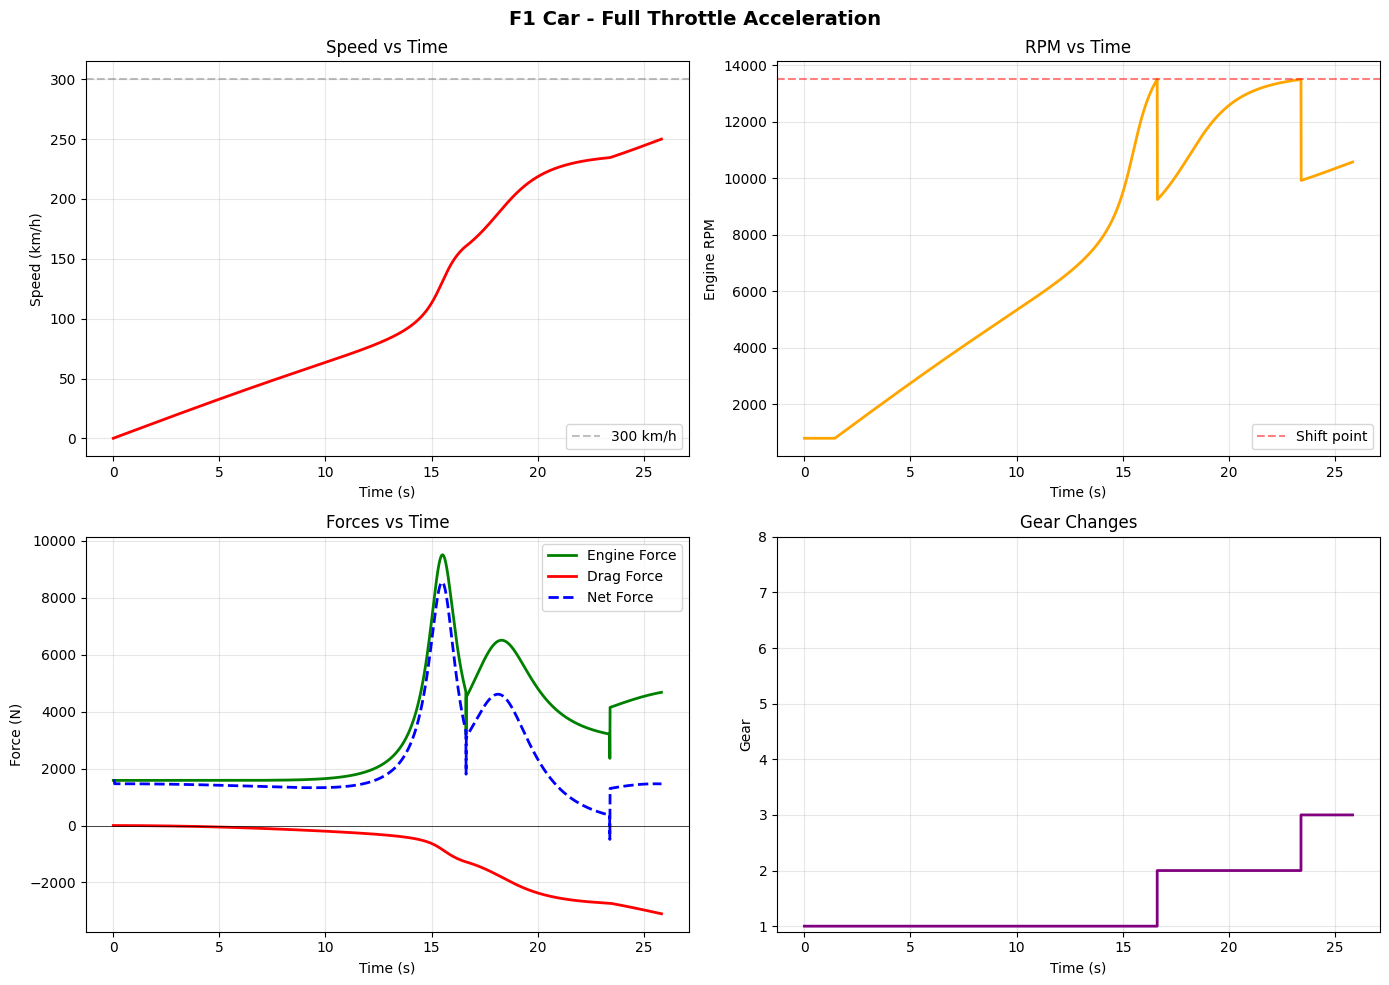

In [9]:
class F1Engine:
    """
    Simple 1D F1 engine + drivetrain simulation.
    No lateral forces yet - just pure forward/backward physics.
    
    State variables:
        rpm      - current engine RPM
        gear     - current gear (1-8)
        velocity - car speed in m/s
        position - car position in meters
    """
    
    # ── Aerodynamic constants (F1 specific) ───────────────────────────────
    DRAG_COEFFICIENT  = 0.7     # Cd - F1 has high drag due to wings
    FRONTAL_AREA      = 1.5     # m² - frontal cross section
    AIR_DENSITY       = 1.225   # kg/m³ - air at sea level
    
    # precomputed: 0.5 * Cd * A * rho
    AERO_DRAG_K       = 0.5 * DRAG_COEFFICIENT * FRONTAL_AREA * AIR_DENSITY
    
    ROLLING_RESIST    = 0.015   # rolling resistance coefficient
    MAX_BRAKE_FORCE   = 25000   # N - F1 brakes are incredibly powerful
    
    RPM_IDLE          = 800
    RPM_REDLINE       = 15000
    
    def __init__(self):
        self.rpm        = self.RPM_IDLE
        self.gear       = 1
        self.velocity   = 0.0    # m/s
        self.position   = 0.0    # m
        self.time       = 0.0    # s
        
        # history for plotting
        self.history = {
            'time': [], 'velocity_ms': [], 'velocity_kmh': [],
            'rpm': [], 'gear': [], 'position': [],
            'engine_force': [], 'drag_force': [], 'net_force': [],
            'acceleration': []
        }
    
    def _rpm_from_velocity(self, velocity, gear):
        """
        Back-calculate what RPM the engine SHOULD be at
        given current wheel speed and gear.
        
        wheel_angular_velocity = velocity / wheel_radius
        engine_rpm = wheel_angular_velocity * gear_ratio * final_drive * (60/2pi)
        """
        if gear == 'N' or velocity <= 0:
            return self.RPM_IDLE
        
        wheel_omega = velocity / WHEEL_RADIUS                          # rad/s
        engine_omega = wheel_omega * GEAR_RATIOS[gear] * FINAL_DRIVE_RATIO
        rpm = engine_omega * (60 / (2 * np.pi))
        return np.clip(rpm, self.RPM_IDLE, self.RPM_REDLINE)
    
    def _auto_shift(self):
        """
        Simple automatic gearbox logic.
        Shift up when RPM hits 90% of redline.
        Shift down when RPM drops below 40% of redline.
        """
        if self.rpm > self.RPM_REDLINE * 0.90 and self.gear < 8:
            self.gear += 1
        elif self.rpm < self.RPM_REDLINE * 0.40 and self.gear > 1:
            self.gear -= 1
    
    def step(self, throttle, brake, dt=0.01, auto_shift=True):
        """
        Single physics timestep.
        
        throttle : 0.0 to 1.0 - how much gas
        brake    : 0.0 to 1.0 - how hard braking
        dt       : timestep in seconds (0.01 = 10ms = 100Hz)
        """
        # ── 1. Sync RPM to wheel speed ─────────────────────────────────
        self.rpm = self._rpm_from_velocity(self.velocity, self.gear)
        
        # ── 2. Auto shift if enabled ───────────────────────────────────
        if auto_shift:
            self._auto_shift()
        
        # ── 3. Calculate engine force ──────────────────────────────────
        engine_force = get_wheel_force(self.rpm, self.gear, throttle)
        
        # ── 4. Aerodynamic drag (grows with v²) ────────────────────────
        # This is why F1 cars need so much power at high speed -
        # drag force at 300 km/h is MASSIVE
        drag_force = self.AERO_DRAG_K * self.velocity**2
        
        # ── 5. Rolling resistance (small, roughly constant) ────────────
        rolling_force = self.ROLLING_RESIST * CAR_MASS * 9.81
        
        # ── 6. Braking force ───────────────────────────────────────────
        brake_force = brake * self.MAX_BRAKE_FORCE
        
        # ── 7. Net force (all resistances oppose motion) ───────────────
        if self.velocity > 0.1:
            resistance = drag_force + rolling_force + brake_force
        elif self.velocity < -0.1:
            resistance = -(drag_force + rolling_force + brake_force)
        else:
            resistance = 0
            if abs(engine_force) < rolling_force + brake_force:
                engine_force = 0  # car stays still if not enough force
        
        net_force    = engine_force - resistance
        
        # ── 8. Newton's 2nd law: F = ma ────────────────────────────────
        acceleration = net_force / CAR_MASS
        
        # ── 9. Integrate velocity and position ─────────────────────────
        self.velocity = max(0.0, self.velocity + acceleration * dt)
        self.position += self.velocity * dt
        self.time     += dt
        
        # ── 10. Record history ─────────────────────────────────────────
        self.history['time'].append(self.time)
        self.history['velocity_ms'].append(self.velocity)
        self.history['velocity_kmh'].append(self.velocity * 3.6)
        self.history['rpm'].append(self.rpm)
        self.history['gear'].append(self.gear)
        self.history['position'].append(self.position)
        self.history['engine_force'].append(engine_force)
        self.history['drag_force'].append(drag_force)
        self.history['net_force'].append(net_force)
        self.history['acceleration'].append(acceleration)

# ── Run a test scenario: full throttle from 0 to 300 km/h ─────────────────
sim = F1Engine()
TARGET_KMH = 250

while sim.history['velocity_kmh'][-1] < TARGET_KMH if sim.history['velocity_kmh'] else True:
    sim.step(throttle=1.0, brake=0.0, dt=0.01)
    if sim.time > 60:  # safety cutoff
        break

h = sim.history
print(f"Reached {TARGET_KMH} km/h in: {sim.time:.2f} seconds")
print(f"Distance covered:            {sim.position:.1f} meters")
print(f"Final gear:                  {sim.gear}")

# ── Plot results ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('F1 Car - Full Throttle Acceleration', fontsize=14, fontweight='bold')

# Speed
axes[0,0].plot(h['time'], h['velocity_kmh'], color='red', linewidth=2)
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Speed (km/h)')
axes[0,0].set_title('Speed vs Time')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axhline(y=300, color='gray', linestyle='--', alpha=0.5, label='300 km/h')
axes[0,0].legend()

# RPM with gear changes marked
axes[0,1].plot(h['time'], h['rpm'], color='orange', linewidth=2)
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Engine RPM')
axes[0,1].set_title('RPM vs Time')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(y=sim.RPM_REDLINE * 0.9, color='red', linestyle='--', 
                   alpha=0.5, label='Shift point')
axes[0,1].legend()

# Forces
axes[1,0].plot(h['time'], h['engine_force'], color='green', 
               linewidth=2, label='Engine Force')
axes[1,0].plot(h['time'], [-d for d in h['drag_force']], color='red',   
               linewidth=2, label='Drag Force')
axes[1,0].plot(h['time'], h['net_force'],    color='blue',  
               linewidth=2, label='Net Force', linestyle='--')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Force (N)')
axes[1,0].set_title('Forces vs Time')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(y=0, color='black', linewidth=0.5)

# Gear
axes[1,1].step(h['time'], h['gear'], color='purple', linewidth=2, where='post')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Gear')
axes[1,1].set_title('Gear Changes')
axes[1,1].set_yticks(range(1, 9))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Braking from 219 km/h
Braking distance: 55.7 meters
Braking time:     1.85 seconds


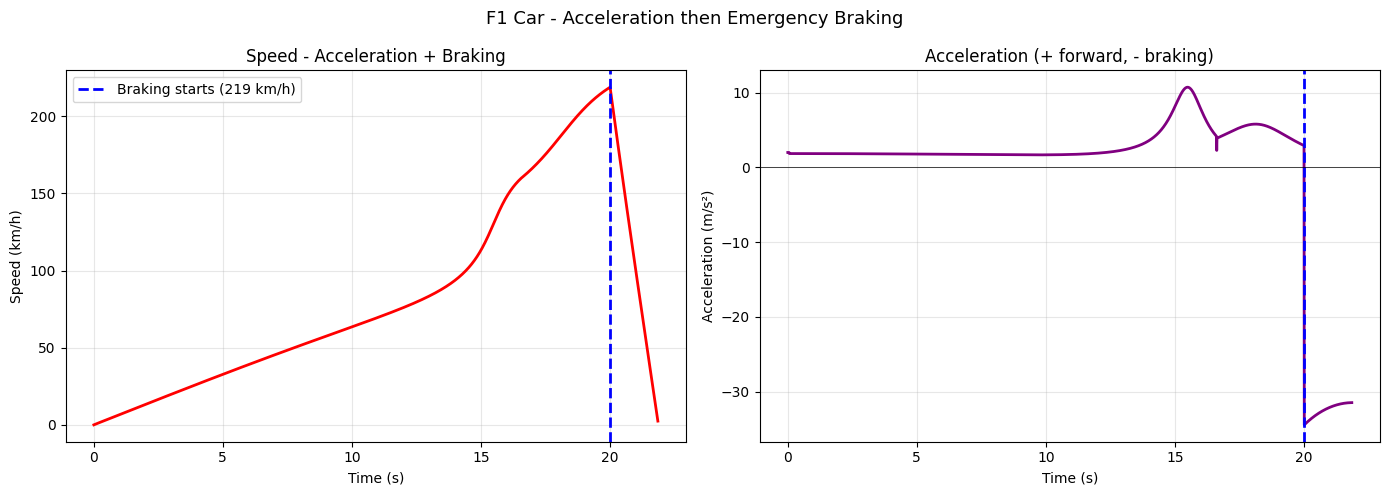

In [10]:
# ── Test: Full throttle then emergency braking ─────────────────────────────
sim2 = F1Engine()

# Phase 1: accelerate to 250 km/h
while (sim2.history['velocity_kmh'][-1] if sim2.history['velocity_kmh'] else 0) < 250:
    sim2.step(throttle=1.0, brake=0.0, dt=0.01)
    if sim2.time > 20:
        break

brake_start_time = sim2.time
brake_start_pos  = sim2.position
brake_start_vel  = sim2.velocity * 3.6

# Phase 2: emergency braking until stopped
while sim2.velocity > 1.0:
    sim2.step(throttle=0.0, brake=1.0, dt=0.01)
    if sim2.time > 40:
        break

braking_distance = sim2.position - brake_start_pos

print(f"Braking from {brake_start_vel:.0f} km/h")
print(f"Braking distance: {braking_distance:.1f} meters")
print(f"Braking time:     {sim2.time - brake_start_time:.2f} seconds")

h2 = sim2.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F1 Car - Acceleration then Emergency Braking', fontsize=13)

ax1.plot(h2['time'], h2['velocity_kmh'], color='red', linewidth=2)
ax1.axvline(x=brake_start_time, color='blue', linestyle='--', 
            linewidth=2, label=f'Braking starts ({brake_start_vel:.0f} km/h)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Speed (km/h)')
ax1.set_title('Speed - Acceleration + Braking')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(h2['time'], h2['acceleration'], color='purple', linewidth=2)
ax2.axvline(x=brake_start_time, color='blue', linestyle='--', linewidth=2)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('Acceleration (+ forward, - braking)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ✅ What we built so far

- Torque curve formula with tuneable F1 character
- 8-speed gearbox with realistic F1 ratios
- Full drivetrain calculation (engine → gearbox → differential → wheel force)
- Aerodynamic drag (grows with v²)
- Braking force
- Physics integration loop (F=ma → velocity → position)
- Auto shifting logic

## ❌ What's missing (next steps)

1. **Slip Ratio** - right now wheels never spin or lock up
   - wheels always have perfect traction
   - we need to model the wheel's own angular velocity separately
   
2. **Lateral forces / Slip Angle** - no turning at all yet
   - Pacejka Magic Formula
   - this is what makes the car actually steer

3. **Weight transfer** - braking shifts weight forward
   - front tires get more grip when braking
   - rear tires get more grip when accelerating
   
4. **Downforce** - at high speed, F1 wings push car into road
   - increases grip proportional to v²
   - opposite effect to drag

5. **2D chassis** - right now car has no position on a track
   - need heading, steering input, full 2D rigid body

## Next notebook: tire.py → slip ratio → lateral forces